In [1]:
import matplotlib.pyplot as plt
from useful_functions_for_models import *
import pandas as pd

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
df=pd.read_csv("datas/pokemon_cards.csv")
df.head()

,id,name,rarity,collection,series,holofoil_price,reverse_holofoil_price,release_date,nationalPokedexNumbers,artist,images_url,popularity_rank
0,dp3-1,Ampharos,Rare Holo,Secret Wonders,Diamond & Pearl,14.73,9.99,2007/11/01,[181],Kouki Saitou,https://images.pokemontcg.io/dp3/1_hires.png,#41
1,ex12-1,Aerodactyl,Rare Holo,Legend Maker,EX,21.21,32.65,2006/02/01,[142],Hajime Kusajima,https://images.pokemontcg.io/ex12/1_hires.png,Not Referenced
2,ex7-1,Azumarill,Rare Holo,Team Rocket Returns,EX,24.91,15.41,2004/11/01,[184],Sumiyoshi Kizuki,https://images.pokemontcg.io/ex7/1_hires.png,Not Referenced
3,sm9-1,Celebi & Venusaur-GX,Rare Holo GX,Team Up,Sun & Moon,12.45,NaN,2019/02/01,"[3, 251]",Mitsuhiro Arita,https://images.pokemontcg.io/sm9/1_hires.png,#84
4,pl1-2,Blastoise,Rare Holo,Platinum,Platinum,20.42,12.34,2009/02/11,[9],Kagemaru Himeno,https://images.pokemontcg.io/pl1/2_hires.png,#106


In [3]:
ids = df['id'].tolist()

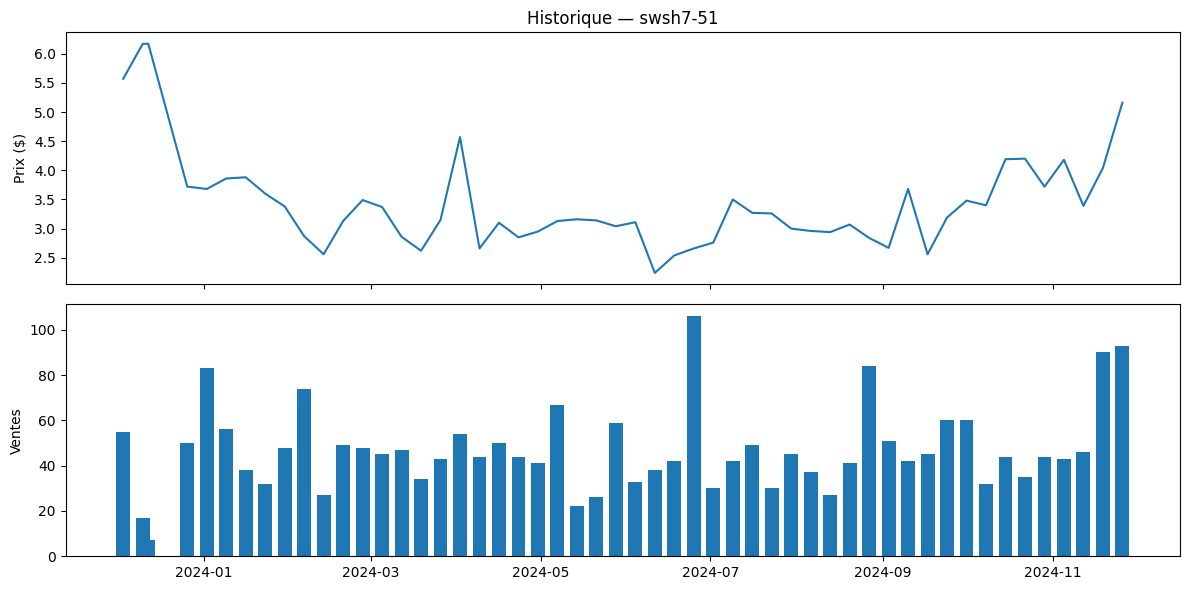

In [4]:
plot_card_history("swsh7-51")

In [5]:
cards_info = get_dataframe_cards_matrix()

/Users/nayelbenabdesadok/opt/anaconda3/envs/pokemon_card/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/nayelbenabdesadok/opt/anaconda3/envs/pokemon_card/lib/python3.9/site-packages/numpy/core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/Users/nayelbenabdesadok/opt/anaconda3/envs/pokemon_card/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/nayelbenabdesadok/opt/anaconda3/envs/pokemon_card/lib/python3.9/site-packages/numpy/core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/Users/nayelbenabdesadok/opt/anaconda3/envs/pokemon_card/lib/python3.9/site-packages/pandas/core/arraylike.p

In [6]:
cards_info.head()

,card_id,last_price,mean_return,Quantity Sold,Card Info
0,swsh10tg-TG20_Holofoil,6.08,0.03,1379,start_date end_date price quantity_so...
1,swsh6-174_Holofoil,43.37,-0.02,359,start_date end_date price quantity_so...
2,xyp-XY113_Holofoil,10.55,-0.08,112,start_date end_date price quantity_so...
3,dpp-DP01_Holofoil,5.89,-0.00,24,start_date end_date price quantity_so...
4,sv3-205_Holofoil,6.95,-0.18,3951,start_date end_date price quantity_so...


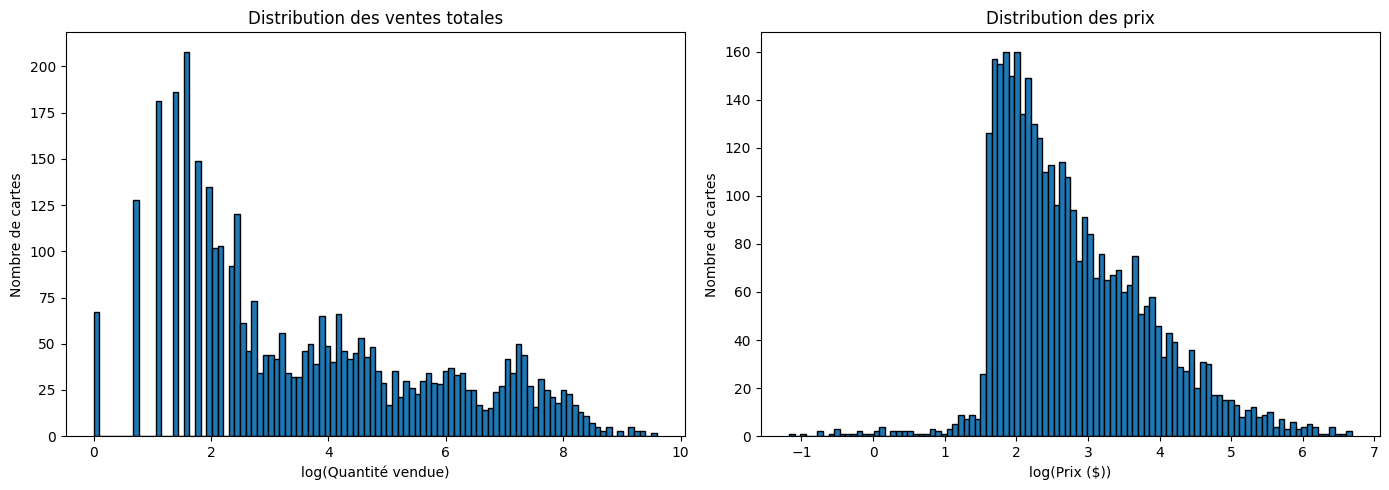

In [8]:
plot_distributions(cards_info,log_scale=True)

In [17]:
import matplotlib.pyplot as plt
import numpy as np

def plot_price_volume_scatter(cards_df):
    """
    Affiche un scatter plot de log(prix) vs log(volume total) pour vérifier 
    l'hypothèse de la courbe en U inversé concernant la liquidité du marché.

    Args:
        cards_df (pd.DataFrame): Sortie contenant les colonnes 'last_price' et 'Quantity Sold'.
    """
    # 1. Nettoyage : on ne garde que les prix et volumes strictement positifs pour le log
    data = cards_df[['last_price', 'Quantity Sold']].dropna()
    data = data[(data['last_price'] > 0) & (data['Quantity Sold'] > 0)]
    
    # 2. Calcul des logarithmes
    log_price = np.log(data['last_price'])
    log_volume = np.log(data['Quantity Sold'])
    
    # 3. Création du graphique
    plt.figure(figsize=(10, 6))
    
    # Scatter plot avec transparence pour bien voir les zones de densité
    plt.scatter(log_price, log_volume, alpha=0.3, edgecolor='none', label='Cartes')
    
    # 4. Ajout d'une ligne de tendance (Polynôme de degré 2) pour vérifier le U inversé
    try:
        z = np.polyfit(log_price, log_volume, 2)
        p = np.poly1d(z)
        
        # Génération des points pour tracer la courbe lisse
        x_trend = np.linspace(log_price.min(), log_price.max(), 100)
        plt.plot(x_trend, p(x_trend), color='red', linestyle='--', linewidth=2, 
                 label='Tendance (degré 2)')
    except Exception as e:
        print("Impossible de tracer la ligne de tendance :", e)

    # 5. Mise en forme
    plt.title('Liquidité vs Prix : log(Volume) en fonction de log(Prix)')
    plt.xlabel('log(Prix) [basé sur last_price]')
    plt.ylabel('log(Volume total) [basé sur Quantity Sold]')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

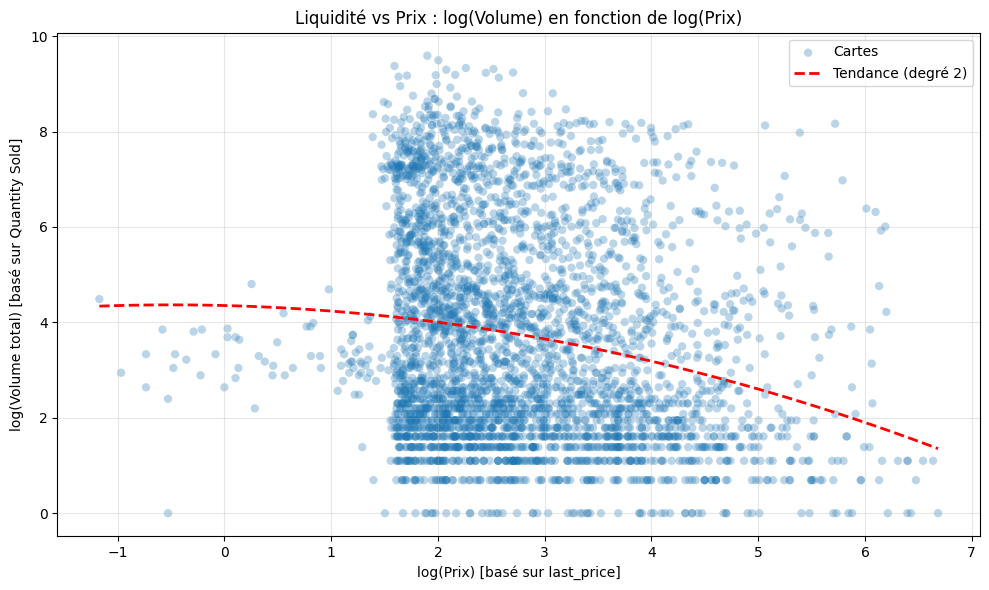

In [18]:
plot_price_volume_scatter(cards_info)